In [6]:
import torch
import torch.nn as nn
import numpy as np
from torch.autograd import grad
import torch.optim as optim
import math
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts

torch.set_default_dtype(torch.float64)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Model parameters
param = {
    # Initial condition
    'p0': 1,
    "mu": 0.2,
    "sigma": 0.4,
    "theta": 0.1,
    "kappa": 1.0,
    "nu": 0.15,
    "rho": 0.5,
    "r": 0.01,
    "gamma": 5.0,
    # Transaction cost params
    "ap": 1.0005,  # ap = 1 + zeta_p
    "bp": 0.9995,  # bp = 1 - eta_p
    "aq": 1.0005,  # aq = 1 + zeta_q
    "bq": 0.9995,  # bq = 1 - eta_q
    # Domain
    "T": 1.0
}

# A_minus and A_plus
def A_minus(p, x):
    # A- = (a_p - b_q * exp(x)) * p
    return (param["ap"] - param["bq"] * torch.exp(x)) * p

def A_plus(p, x):
    # A+ = (b_p - a_q * exp(x)) * p
    return (param["bp"] - param["aq"] * torch.exp(x)) * p

# Terminal payoff, i.e., liquidated value of the portfolio
# J(p(T), x(T), y(T)) = A+ * y 1{y>=0} + A- * y 1{y<0}
def terminal_J(p, x, y):
    return torch.where(y >= 0, A_plus(p, x) * y, A_minus(p, x) * y)

# Neural network for u(t,p,x,y) = log H(t, p, x, y)
class Net(nn.Module):
    def __init__(self, n_in, n_out=1, layers=[64, 64, 64, 64, 64]):
        super().__init__()
        seq = [nn.Linear(n_in, layers[0]), nn.Tanh()]
        for i in range(len(layers)-1):
            seq += [nn.Linear(layers[i], layers[i+1]), nn.Tanh()]
        seq.append(nn.Linear(layers[-1], n_out))
        self.net = nn.Sequential(*seq)
    def forward(self, *args):
        x = torch.cat([a if a.ndim > 1 else a.unsqueeze(1) for a in args], dim=1)
        return self.net(x).squeeze(-1)
    
class BoundaryNet(nn.Module):         # SINGLE network → (center, width) → (Yb, Ys)
    def __init__(self):
        super().__init__()
        self.center = nn.Sequential(
            nn.Linear(3, 80), nn.Tanh(),
            nn.Linear(80, 80), nn.Tanh(),
            nn.Linear(80, 80), nn.Tanh(),
            nn.Linear(80, 80), nn.Tanh(),
            nn.Linear(80, 1)
        )
        self.width = nn.Sequential(      # Forces positive width → Yb < Ys always
            nn.Linear(3, 80), nn.Tanh(),
            nn.Linear(80, 80), nn.Tanh(),
            nn.Linear(80, 80), nn.Tanh(),
            nn.Linear(80, 80), nn.Tanh(),
            nn.Linear(80, 1),
            nn.Softplus()
        )
        
    def forward(self, t, p, x):
        inp = torch.cat([t.unsqueeze(1), p.unsqueeze(1), x.unsqueeze(1)], dim=1)
        center = self.center(inp).squeeze(-1)
        width  = self.width(inp).squeeze(-1) + 0.5   # minimum width 0.5 → prevents collapse
        return center - width/2, center + width/2   # Yb, Ys


net_u  = Net(4).to(device)          # u = log H(t,p,x,y)
net_bound = BoundaryNet().to(device)

# Domain bounds
t_min, t_max = 0.0, param['T']
p_min, p_max = 0.3, 4.0
x_min, x_max = -0.5, 0.5
y_min, y_max = -10, 10

# Sample function for t, p, x
def sample_tpx(batch_size):
    t = torch.rand(batch_size, device=device) * (t_max - t_min) + t_min
    p = torch.rand(batch_size, device=device) * (p_max - p_min) + p_min
    x = torch.rand(batch_size, device=device) * (x_max - x_min) + x_min
    t.requires_grad = True
    p.requires_grad = True
    x.requires_grad = True
    return t, p, x

# PDE residual for u = log H (transformed L_{2,o} H = 0)
def pde_residual(u, t, p, x, y):
    grads = torch.autograd.grad(u, (t, p, x, y), 
                               grad_outputs=torch.ones_like(u),
                               create_graph=True, retain_graph=True)
    du_t, du_p, du_x = grads[0], grads[1], grads[2]

    # Second derivatives
    du_pp = torch.autograd.grad(du_p, p, torch.ones_like(du_p), create_graph=True)[0]
    du_xx = torch.autograd.grad(du_x, x, torch.ones_like(du_x), create_graph=True)[0]
    du_px = torch.autograd.grad(du_p, x, torch.ones_like(du_p), create_graph=True)[0]

    res = (du_t
            + param["kappa"]*(param["theta"] - x)*du_x
            + param["mu"]*p*du_p
            + 0.5*param["nu"]**2 * (du_xx + du_x**2)
            + param["rho"]*param["nu"]*param["sigma"]*p * (du_px + du_p*du_x)
            + 0.5*(param["sigma"]*p)**2 * (du_pp + du_p**2))
    return res

# 2. Loss weights
w_pde   = 1.0
w_buy   = 50     
w_sell  = 50     
w_bc    = 20
w_term  = 5

# Loss function
def compute_loss(n_batch=2000, delta_out=4.0):
    # Common points
    t, p, x = sample_tpx(n_batch)
    yb, ys = net_bound(t, p, x)

    # No-transaction region (interior)
    mask = yb < ys
    if mask.any():
        t_i, p_i, x_i, yb_i, ys_i = t[mask], p[mask], x[mask], yb[mask], ys[mask]
        # Fresh leaf variable for y
        xi = torch.rand_like(yb_i)
        y_i = yb_i + xi * (ys_i - yb_i)
        y_i.requires_grad_(True)                   
        u_i = net_u(t_i, p_i, x_i, y_i)
        loss_pde = torch.mean(pde_residual(u_i, t_i, p_i, x_i, y_i)**2)
    else:
        loss_pde = torch.tensor(0.0, device=device)

    # Buy region
    y_buy = yb - torch.rand_like(yb) * delta_out
    y_buy.requires_grad_(True)
    u_buy = net_u(t, p, x, y_buy)   # u(t,p,x,y)  where y = log H at a point inside buy region
    u_b   = net_u(t, p, x, yb)      # u(t,p,x,Y_b) = log H on the buy boundary
    target_buy = u_b - param["gamma"] * torch.exp(param["r"]*(param["T"]-t)) * A_minus(p, x) * (y_buy - yb)
    loss_buy = torch.mean((u_buy - target_buy)**2)

    # Sell region
    y_sell = ys + torch.rand_like(ys) * delta_out
    y_sell.requires_grad_(True)
    u_sell = net_u(t, p, x, y_sell)
    u_s   = net_u(t, p, x, ys)
    target_sell = u_s - param["gamma"] * torch.exp(param["r"]*(param["T"]-t)) * A_plus(p, x) * (y_sell - ys)
    loss_sell = torch.mean((u_sell - target_sell)**2)

    # Boundary conditions (smooth pasting)
    # buy boundary
    yb_bc = yb.clone().detach().requires_grad_(True)
    ys_bc = ys.clone().detach().requires_grad_(True)
    grad_b = torch.autograd.grad(net_u(t,p,x,yb_bc), yb_bc, torch.ones_like(yb_bc), create_graph=True)[0]
    grad_s = torch.autograd.grad(net_u(t,p,x,ys_bc), ys_bc, torch.ones_like(ys_bc), create_graph=True)[0]
    loss_sp = torch.mean((grad_b + param["gamma"]*torch.exp(param["r"]*(param["T"]-t))*A_minus(p,x))**2) + \
              torch.mean((grad_s + param["gamma"]*torch.exp(param["r"]*(param["T"]-t))*A_plus(p,x))**2)


    # Terminal condition
    y_term = torch.rand(n_batch, device=device) * (y_max - y_min) + y_min
    t_term = torch.full((n_batch,), param["T"], device=device)
    p_term, x_term = sample_tpx(n_batch)[1], sample_tpx(n_batch)[2]
    u_term = net_u(t_term, p_term, x_term, y_term)
    loss_term = torch.mean((u_term + param["gamma"] * terminal_J(p_term, x_term, y_term))**2)

    total = (w_pde  * loss_pde +
             w_buy * loss_buy +
             w_sell * loss_sell +
             w_bc * loss_sp +
             w_term * loss_term)
    
    return total


optimizer = torch.optim.Adam(list(net_u.parameters()) +
                            list(net_bound.parameters()), lr=8e-4)

scheduler = CosineAnnealingWarmRestarts(
    optimizer, 
    T_0=10000,      # First cycle length (epochs)
    T_mult=2,      # Each restart doubles the cycle length
    eta_min=1e-6   # Minimum LR (prevents stalling)
)

# Training loop
training_params = {'epochs': 40000,
                   'n_batch': 5000}

for epoch in range(training_params["epochs"]):
    optimizer.zero_grad()
    loss = compute_loss(n_batch=training_params["n_batch"])
    loss.backward()

    torch.nn.utils.clip_grad_norm_(list(net_u.parameters()) + list(net_bound.parameters()), 1.0)

    optimizer.step()
    scheduler.step()

    if epoch % 1000 == 0:
        print(f"Epoch {epoch:5d}  loss = {loss.item():.3e}")

print("Training finished!")

Epoch     0  loss = 9.704e+03
Epoch  1000  loss = 6.748e+02
Epoch  2000  loss = 2.928e+02
Epoch  3000  loss = 1.356e+02
Epoch  4000  loss = 6.591e+01
Epoch  5000  loss = 3.178e+01
Epoch  6000  loss = 1.840e+01
Epoch  7000  loss = 1.224e+01
Epoch  8000  loss = 6.611e+00
Epoch  9000  loss = 5.987e+00
Epoch 10000  loss = 5.476e+00
Epoch 11000  loss = 8.188e+00
Epoch 12000  loss = 5.871e+00
Epoch 13000  loss = 6.160e+00
Epoch 14000  loss = 6.007e+00
Epoch 15000  loss = 3.442e+00
Epoch 16000  loss = 4.241e+00
Epoch 17000  loss = 1.311e+00
Epoch 18000  loss = 1.213e+00
Epoch 19000  loss = 1.083e+00
Epoch 20000  loss = 9.666e-01
Epoch 21000  loss = 9.927e-01
Epoch 22000  loss = 5.193e-01
Epoch 23000  loss = 9.962e-01
Epoch 24000  loss = 4.199e-01
Epoch 25000  loss = 2.567e-01
Epoch 26000  loss = 3.105e-01
Epoch 27000  loss = 2.691e-01
Epoch 28000  loss = 3.858e-01
Epoch 29000  loss = 3.552e-01
Epoch 30000  loss = 1.770e-01
Epoch 31000  loss = 1.252e+01
Epoch 32000  loss = 1.863e+00
Epoch 3300

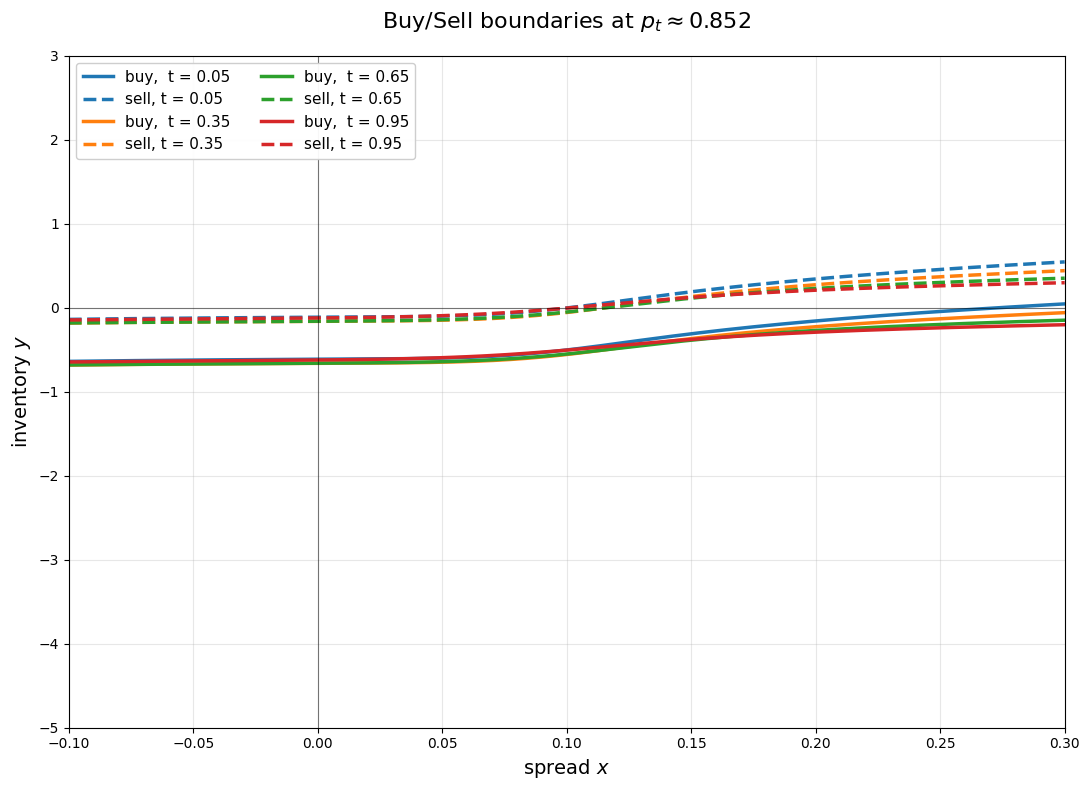

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# === SETTINGS ===
p_fixed = 0.852          # As in Xing's Figure 1
x_grid = torch.linspace(-0.10, 0.30, 1000, device=device)  # Focus on relevant spread range
times = [0.05, 0.35, 0.65, 0.95]   # Same as in the paper
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']  # Classic matplotlib colors
labels = [f't = {t:.2f}' for t in times]

plt.figure(figsize=(11, 8))

with torch.no_grad():
    for i, t_val in enumerate(times):
        t_tensor = torch.full_like(x_grid, t_val)
        p_tensor = torch.full_like(x_grid, p_fixed)
        
        yb, ys = net_bound(t_tensor, p_tensor, x_grid)
        
        yb_np = yb.cpu().numpy()
        ys_np = ys.cpu().numpy()
        x_np  = x_grid.cpu().numpy()
        
        color = colors[i]
        
        # Buy boundary (lower)
        plt.plot(x_np, yb_np, color=color, linewidth=2.5, 
                 label=f'buy, {labels[i]}')
        
        # Sell boundary (upper)
        plt.plot(x_np, ys_np, color=color, linestyle='--', linewidth=2.5,
                 label=f'sell, {labels[i]}')

# === FINAL POLISH — exactly like Xing's figure ===
plt.xlabel('spread $x$', fontsize=14)
plt.ylabel('inventory $y$', fontsize=14)
plt.title(f'Buy/Sell boundaries at $p_t \\approx {p_fixed:.3f}$', fontsize=16, pad=20)

plt.xlim(-0.10, 0.30)
plt.ylim(-5, 3)
plt.grid(True, alpha=0.3)
plt.axhline(0, color='black', linewidth=0.8, alpha=0.5)
plt.axvline(0, color='black', linewidth=0.8, alpha=0.5)

# Custom legend: one entry per time, with solid + dashed
handles, legend_labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(legend_labels, handles))  # remove duplicates
sorted_items = sorted(by_label.items(), key=lambda x: float(x[0].split('=')[-1]))

# Reorder legend: buy then sell for each time
ordered_handles = []
ordered_labels  = []
for t in times:
    t_str = f't = {t:.2f}'
    ordered_labels.append(f'buy,  {t_str}')
    ordered_labels.append(f'sell, {t_str}')
    ordered_handles.append(by_label[f'buy, {t_str}'])
    ordered_handles.append(by_label[f'sell, {t_str}'])

plt.legend(ordered_handles, ordered_labels, 
           ncol=2, fontsize=11, loc='upper left', framealpha=0.95)

plt.tight_layout()
plt.show()